
# Exploring Convolutional Layers Through Data and Experiments

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

## 1. Dataset exploration (EDA)

Download the dataset from Kaggle (https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals) and place it in DB/animals relative to the repo.

In [ ]:
dataset_dir = "DB/animals"  # relative path

### Dataset size and class distribution

In [22]:
import os
from collections import Counter

class_counts = {}
total_images = 0

for root, dirs, files in os.walk(dataset_dir):
    if files:
        class_name = os.path.basename(root)
        num_images = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[class_name] = num_images
        total_images += num_images

print(f"Total images: {total_images}")
print(f"Total classes: {len(class_counts)}")

for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

Total images: 5400
Total classes: 90
antelope: 60 images
badger: 60 images
bat: 60 images
bear: 60 images
bee: 60 images
beetle: 60 images
bison: 60 images
boar: 60 images
butterfly: 60 images
cat: 60 images
caterpillar: 60 images
chimpanzee: 60 images
cockroach: 60 images
cow: 60 images
coyote: 60 images
crab: 60 images
crow: 60 images
deer: 60 images
dog: 60 images
dolphin: 60 images
donkey: 60 images
dragonfly: 60 images
duck: 60 images
eagle: 60 images
elephant: 60 images
flamingo: 60 images
fly: 60 images
fox: 60 images
goat: 60 images
goldfish: 60 images
goose: 60 images
gorilla: 60 images
grasshopper: 60 images
hamster: 60 images
hare: 60 images
hedgehog: 60 images
hippopotamus: 60 images
hornbill: 60 images
horse: 60 images
hummingbird: 60 images
hyena: 60 images
jellyfish: 60 images
kangaroo: 60 images
koala: 60 images
ladybugs: 60 images
leopard: 60 images
lion: 60 images
lizard: 60 images
lobster: 60 images
mosquito: 60 images
moth: 60 images
mouse: 60 images
octopus: 60 ima

### Image dimensions and channels

In [27]:
from PIL import Image
import random

image_shapes = []

all_images = []
for root, _, files in os.walk(dataset_dir):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, f))

sample_images = random.sample(all_images, 10)

for img_path in sample_images:
    img = Image.open(img_path)
    image_shapes.append((img.size, img.mode))

for shape in image_shapes:
    print("Dimensions:", shape[0], "Mode:", shape[1])

Dimensions: (976, 549) Mode: RGB
Dimensions: (275, 183) Mode: RGB
Dimensions: (275, 183) Mode: RGB
Dimensions: (250, 202) Mode: RGB
Dimensions: (275, 183) Mode: RGB
Dimensions: (1024, 715) Mode: RGB
Dimensions: (225, 225) Mode: RGB
Dimensions: (2000, 1434) Mode: RGB
Dimensions: (1920, 1080) Mode: RGB
Dimensions: (225, 225) Mode: RGB


The images in the dataset are in color, with three channels (RGB). However, the dimensions vary significantly between samples, with resolutions ranging from approximately 200×170 pixels to over 2000×1000 pixels.

This variability makes a resizing process necessary before training, in order to ensure consistent inputs for the convolutional network.

In [28]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

As part of preprocessing, the images are resized to 224×224 pixels, converted to tensors, and normalized. This allows for stable training and makes it easier to compare different convolutional architectures.

### Example images from different classes (random selection of 9)

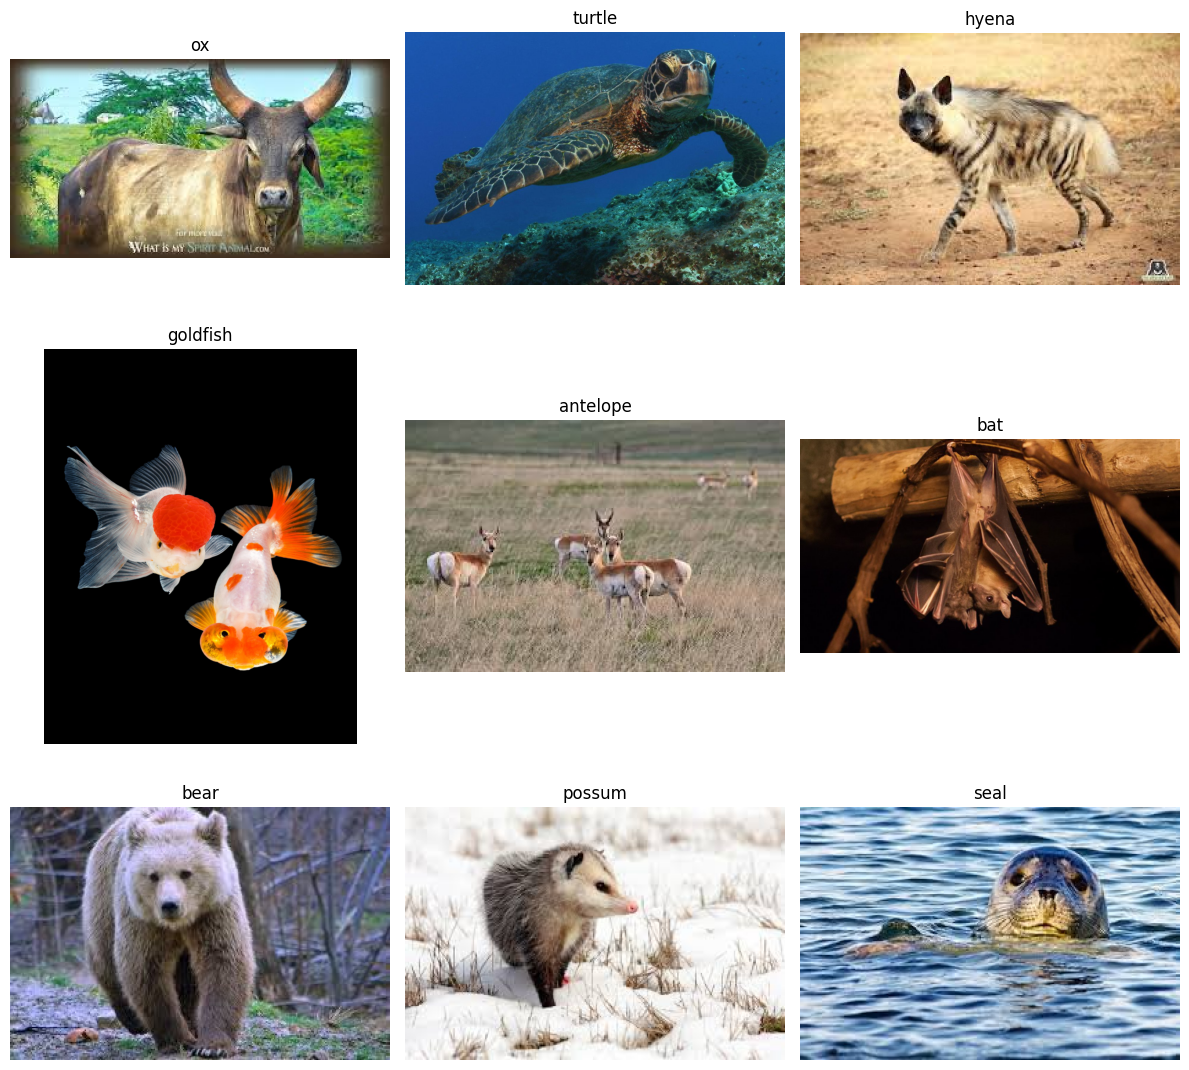

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

dataset_dir = "DB/animals/animals"  # relative path

subfolders = [os.path.join(dataset_dir, f) for f in os.listdir(dataset_dir) 
              if os.path.isdir(os.path.join(dataset_dir, f))]

selected_folders = random.sample(subfolders, 9)

plt.figure(figsize=(12, 12))

for i, folder in enumerate(selected_folders):
    images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    img_name = random.choice(images)
    img_path = os.path.join(folder, img_name)
    img = Image.open(img_path)
    
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(os.path.basename(folder))
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Baseline Model (Non-Convolutional)

In [33]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

dataset = ImageFolder(root=dataset_dir, transform=transform)
print("Total samples:", len(dataset))

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Total samples: 5400
Train samples: 4320
Validation samples: 1080


#### Architecture description

A baseline neural network without convolutional layers was implemented in order to establish a reference point for performance comparison. The goal of this model is to evaluate how a traditional fully connected architecture performs when applied directly to image data.

The images from the dataset were resized to 224×224 pixels with 3 color channels (RGB). Each image is therefore represented as a tensor of size 224 × 224 × 3, which corresponds to 150,528 input features.

The baseline architecture is defined as follows:

- A Flatten layer that converts each image into a 1D vector of 150,528 values.

- A fully connected layer with 512 neurons and ReLU activation.

- A second fully connected layer with 256 neurons and ReLU activation.

- A final output layer with 90 neurons, corresponding to the 90 animal classes.

In [37]:
import torch.nn as nn
import torch.optim as optim

num_classes = len(dataset.classes)

class BaselineNN(nn.Module):
    def __init__(self):
        super(BaselineNN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(224*224*3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = BaselineNN()

total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 77225306


This extremely large number is mainly due to the first dense layer, which connects the 150,528 input features to 512 neurons. Because fully connected layers require one weight per input-output connection, flattening high-resolution images results in a massive parameter count.

Most of the model capacity is therefore concentrated in this first layer, making the network:

- Computationally expensive

- Memory inefficient

- Highly prone to overfitting

This highlights one of the fundamental weaknesses of using dense networks for image-based tasks.

#### Baseline training

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BaselineNN(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=90, bias=True)
  )
)

#### Basic training cycle

In [39]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 9.920932801564534
Epoch 2, Loss: 4.442325330663611
Epoch 3, Loss: 4.415095189765648
Epoch 4, Loss: 4.325626926068907
Epoch 5, Loss: 4.316459971887094


The training performance shows the model is basically stuck at “guessing.” In epoch 1 the loss dropped from 9.92 to 4.44, but then it barely changed: 4.41, 4.32, and 4.31. Loss here means how wrong the model is when predicting. It’s calculated using a log formula: if the model gives the correct class a probability $p$, the loss is $(-\log(p))$. For 90 classes, a random guess means $(p = 1/90)$, so the loss is about 4.50. Since the final training loss of 4.31 is almost the same as that random baseline, the model never learned real patterns, it just kept spreading its guesses across the 90 options, almost like picking at random.

#### Evaluation in validation

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Validation Accuracy:", accuracy)

Validation Accuracy: 2.314814814814815


The validation accuracy numbers show why the model is still close to random guessing. After training, it reached 2.31% accuracy. To see why that’s only slightly better than chance, remember that with 90 possible classes, a random guess has a probability of $1/90$. Converting that to a percentage gives about 1.11% accuracy. In other words, if you just picked answers at random, you’d expect to be right about 1 time out of 90. Since the model’s accuracy is only a little higher than that, it means it didn’t learn useful patterns and can’t generalize well to new data.

#### Observed limitations

The weak results of the baseline model can be traced to several design issues:

- When the images are flattened, the model stops seeing how pixels relate to each other. It treats every pixel as separate, missing the fact that nearby pixels usually form meaningful shapes.

- The type of layers used here don’t naturally detect things like edges, textures, or shapes. These local patterns are crucial for understanding images, but the model has no way to capture them.

- With over 77 million adjustable values, the model is far too large compared to the dataset. This makes training harder and increases the chance of memorizing the data instead of learning general rules.

- Poor generalization because the input is very high‑dimensional and the model lacks structure‑aware processing, it fails to learn useful visual representations. As a result, it cannot perform well on new, unseen images.

## 3. Convolutional Architecture Design

#### Architecture

The proposed CNN consists of:

- Three convolutional layers with increasing depth.

- ReLU activation functions after each convolution.

- MaxPooling layers to progressively reduce spatial dimensions.

- A small fully connected classifier at the end.

In [34]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28 * 128, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [35]:
cnn_model = SimpleCNN(num_classes=90)

In [36]:
total_params = sum(p.numel() for p in cnn_model.parameters())
print("Total parameters:", total_params)

Total parameters: 25806746


#### Training

In [37]:
import torch
import torch.optim as optim

cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model.to(device)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=90, bias=True)
  )
)

##### Training cycle

In [38]:
epochs = 5

for epoch in range(epochs):
    cnn_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        cnn_optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = cnn_criterion(outputs, labels)
        loss.backward()
        cnn_optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 4.466320882020173
Epoch 2, Loss: 4.129768595872102
Epoch 3, Loss: 3.4761089907752143
Epoch 4, Loss: 1.7769375050509417
Epoch 5, Loss: 0.3560969598867275


#### Evaluation of validation

In [39]:
cnn_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy = 100 * correct / total
print("Validation Accuracy CNN:", cnn_accuracy)

Validation Accuracy CNN: 34.72222222222222


#### Justification of design choices

**Number of convolutional layers – 3**

Three convolutional layers were selected to allow the network to learn hierarchical representations:

- Early layers capture simple patterns such as edges.

- Middle layers combine them into textures.

- Deeper layers represent more complex object parts.

This depth provides sufficient representational power while keeping the model simple and interpretable.

**Kernel size – 3×3**

A 3×3 kernel was used in all layers because:

- It effectively captures local spatial patterns. 

- Requires fewer parameters than larger kernels.

- Allows stacking multiple layers to increase receptive field.

**Stride and padding**

- Stride was set to 1 to preserve spatial resolution.

- Padding of 1 was used so that the feature map size remains unchanged after each convolution.

Dimensionality reduction is handled intentionally through pooling rather than large strides.

**Activation function**

ReLU was chosen due to:

- Computational efficiency.

- Non-saturating gradient behavior.

- Standard effectiveness in vision tasks.

**Pooling strategy**

MaxPooling with size 2×2 was applied after each convolutional block in order to:

- Reduce spatial dimensions.

- Introduce translation invariance.

- Lower computational cost.

**About results**

Compared with the baseline model:

- The number of parameters was reduced from 77 million to 25 million.

- Validation accuracy increased from 2.31% to 34.72%.

- Loss decreased consistently across epochs instead of stagnating.

These results demonstrate that convolutional layers provide a much more suitable inductive bias for image data. By exploiting spatial locality and weight sharing, the CNN is able to learn meaningful visual features that the fully connected baseline could not capture.

## 4. Controlled Experiments on the Convolutional Layer

Reducing the number of filters will decrease model complexity and parameters. This may reduce overfitting, but it can also limit the representational power of the CNN.

In [40]:
class CNN_LowFilters(nn.Module):
    def __init__(self, num_classes=90):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_cnn_low = CNN_LowFilters(num_classes=90)

print("Total parameters (Low Filters CNN):",
      sum(p.numel() for p in model_cnn_low.parameters()))

Total parameters (Low Filters CNN): 12892026


#### Training

In [41]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn_low.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn_low.to(device)

CNN_LowFilters(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=90, bias=True)
  )
)

#### Training cycle

In [42]:
epochs = 5

for epoch in range(epochs):
    model_cnn_low.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_cnn_low(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 4.385542837778727
Epoch 2, Loss: 3.8828004448502154
Epoch 3, Loss: 2.833726895297015
Epoch 4, Loss: 1.3439160532421537
Epoch 5, Loss: 0.3393219261809632


#### Evaluation in validation

In [43]:
model_cnn_low.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_cnn_low(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Validation Accuracy CNN Low Filters:", accuracy)

Validation Accuracy CNN Low Filters: 39.629629629629626


A controlled experiment was conducted to evaluate the impact of the number of convolutional filters on model performance. The baseline CNN architecture used the following filter configuration:

- Conv layers: 32 → 64 → 128 filters

For the experiment, a reduced-capacity version of the model was created with:

- Conv layers: 16 → 32 → 64 filters

All other aspects of the architecture and training procedure were kept identical, including kernel sizes, pooling strategy, optimizer, learning rate, number of epochs, and dataset preprocessing. This ensures that the only variable being tested was the number of filters.

| Model             | Filters     | Parameters   | Final loss | Validation accuracy |
|-------------------|-------------|--------------|------------|---------------------|
| CNN Base          | 32-64-128   | 25806746   | 0.356      | 34.72%              |
| CNN Low Filters   | 16-32-64    | 12892026   | 0.339      | 39.63%              |

Reducing the number of filters decreased the total number of parameters by approximately 50%, significantly lowering the computational complexity of the model.

Despite this reduction in capacity, the smaller model achieved better validation performance, increasing accuracy from 34.72% to 39.63%. The final loss was also slightly lower, and the training curve showed more stable and consistent convergence.

These results suggest that the original CNN was over-parameterized for this dataset. The larger number of filters likely caused the model to overfit the training data, while the reduced version provided a better balance between representational power and generalization.

This experiment confirms that the number of filters is a critical architectural hyperparameter. More filters do not necessarily lead to better performance; instead, an appropriate model capacity must be chosen according to dataset size and complexity.

## 5. Interpretation and Architectural Reasoning

#### **Why did convolutional layers outperform (or not) the baseline?**

Convolutional layers outperformed the baseline because they are specifically designed to work with images. The baseline model used only fully connected layers, which required flattening the images into vectors. This process destroys the spatial structure of the data and makes it very hard for the network to learn visual patterns.

Convolutional layers, on the other hand, preserve the two-dimensional structure of images and learn local features such as edges and textures. They also reuse the same filters across the image, which reduces the number of parameters and improves generalization.

As a result, the CNN was able to learn meaningful visual representations, while the baseline model behaved almost like random guessing. This explains the large difference in accuracy between the two approaches.

#### **What inductive bias does convolution introduce?**

Convolution introduces several important assumptions about image data:

Locality: important patterns are formed by nearby pixels, so filters focus on small regions instead of the whole image.

Translation invariance: the same feature can appear anywhere in the image, and the network should recognize it regardless of position.

Parameter sharing: the same filters are reused across the image, reducing complexity and helping the model generalize better.

Hierarchical learning: deeper layers combine simple patterns into more complex ones.

These biases match the natural structure of images and make CNNs much more effective for visual tasks.

#### **In what type of problems would convolution not be appropriate?**

Convolution is not suitable for problems where the data does not have a spatial or grid-like structure. Examples include:

Tabular data, such as financial or medical records, where features have no spatial relationship.

Text or sequential data, where order matters more than spatial locality.

Graph data, such as social networks or molecular structures, which require different types of models.

Very small datasets, where CNNs may be too complex and simpler models work better.

In general, convolution works best when the input has clear spatial patterns like images or videos. When this assumption is not valid, other architectures are more appropriate.